## **Oasis Infobyte Internship** – Task 2
Customer Segmentation Analysis

Objective:
To segment customers based on their purchasing behaviour using
K-Means clustering and identify actionable customer groups.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

uploaded = files.upload()

Saving retail_customer_segmentation.csv to retail_customer_segmentation.csv


In [4]:
df = pd.read_csv("retail_customer_segmentation.csv")

print(df.head())
print(df.shape)
print(df.columns.tolist())

   customer_id  age  annual_income  months_active  avg_monthly_spend  \
0        33554   53  100473.211709             63         121.430565   
1         9428   54   54730.644845             67         572.552674   
2          200   44   58268.121079             57         266.593896   
3        12448   54   64829.795654             40         691.452358   
4        39490   28   27431.467873             15         832.664792   

   purchase_frequency  avg_order_value  discount_usage_rate  return_rate  \
0            0.817268        66.820403             0.117256     0.023144   
1            3.176551       137.087449             0.261647     0.429054   
2            2.713168        71.796888             0.284785     0.011854   
3            5.553977       105.501185             0.104832     0.399686   
4            1.348389       354.568534             0.409204     0.039517   

   browsing_time_minutes  support_interactions payment_method      region  \
0              77.298393         

In [6]:
print("Missing value:")
print(df.isnull().sum())

print("\nDuplicate rows:",df.duplicated().sum())

print("\nData types:")
print(df.dtypes)



Missing value:
customer_id                 0
age                         0
annual_income            3075
months_active               0
avg_monthly_spend        2520
purchase_frequency       1979
avg_order_value             0
discount_usage_rate      2549
return_rate              2487
browsing_time_minutes    3934
support_interactions     1988
payment_method              0
region                      0
customer_segment            0
dtype: int64

Duplicate rows: 0

Data types:
customer_id                int64
age                        int64
annual_income            float64
months_active              int64
avg_monthly_spend        float64
purchase_frequency       float64
avg_order_value          float64
discount_usage_rate      float64
return_rate              float64
browsing_time_minutes    float64
support_interactions     float64
payment_method            object
region                    object
customer_segment          object
dtype: object


In [19]:
# Calculate Customer Lifetime Value (CLV)
df['customer_lifetime_value'] = (
    df['avg_monthly_spend'] * df['months_active']
)

print("CLV calculation completed.")
display(df[['customer_id', 'avg_monthly_spend', 'months_active',
            'customer_lifetime_value']].head())

CLV calculation completed.


,customer_id,avg_monthly_spend,months_active,customer_lifetime_value
0,33554,121.430565,63,7650.125599
1,9428,572.552674,67,38361.029158
2,200,266.593896,57,15195.852087
3,12448,691.452358,40,27658.094329
4,39490,832.664792,15,12489.971884


In [20]:
print("Average Purchase Value:", round(df['avg_order_value'].mean(), 2))
print("Average Purchase Frequency:", round(df['purchase_frequency'].mean(), 2))
print("Average Customer Lifetime Value:", round(df['customer_lifetime_value'].mean(), 2))

Average Purchase Value: 77.38
Average Purchase Frequency: 4.88
Average Customer Lifetime Value: 12223.75


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,50000.0,25000.500000,14433.901067,1.000000,12500.750000,25000.500000,37500.250000,50000.000000
age,50000.0,44.002820,15.269871,18.000000,31.000000,44.000000,57.000000,70.000000
annual_income,46925.0,44542.620904,30537.946035,2946.317892,24373.244554,36787.730010,55497.245522,530788.317921
months_active,50000.0,36.477480,20.787197,1.000000,18.000000,36.000000,55.000000,72.000000
avg_monthly_spend,47480.0,337.294238,204.627095,8.072298,192.074544,297.477404,439.112361,3026.342238
purchase_frequency,48021.0,4.910841,3.416115,0.017013,2.456867,4.158673,6.526903,67.682528
avg_order_value,50000.0,77.375915,70.531793,0.940393,32.018468,56.600351,98.832037,1289.427328
discount_usage_rate,47451.0,0.284358,0.159236,0.000534,0.160497,0.262591,0.387640,0.934655
return_rate,47513.0,0.148964,0.110508,0.000050,0.063938,0.123628,0.209612,0.830395
browsing_time_minutes,46066.0,61.781329,41.743394,0.236109,31.082283,52.679175,82.549571,406.813006


In [8]:
df[['avg_monthly_spend', 'purchase_frequency', 'avg_order_value']] = (
    df[['avg_monthly_spend', 'purchase_frequency', 'avg_order_value']]
    .fillna(df[['avg_monthly_spend', 'purchase_frequency', 'avg_order_value']].median())
)

In [9]:
df[['avg_monthly_spend', 'purchase_frequency', 'avg_order_value']].isnull().sum()

,0
avg_monthly_spend,0
purchase_frequency,0
avg_order_value,0


In [10]:
features = ['avg_monthly_spend', 'purchase_frequency', 'avg_order_value']

X = df[features]

print(X.head())
print("\nFeatures selected:", features)

   avg_monthly_spend  purchase_frequency  avg_order_value
0         121.430565            0.817268        66.820403
1         572.552674            3.176551       137.087449
2         266.593896            2.713168        71.796888
3         691.452358            5.553977       105.501185
4         832.664792            1.348389       354.568534

Features selected: ['avg_monthly_spend', 'purchase_frequency', 'avg_order_value']


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Standardization completed.")
print(X_scaled[:5])

Standardization completed.
[[-1.07147087 -1.21271246 -0.14965758]
 [ 1.18875169 -0.50865964  0.8465988 ]
 [-0.34417015 -0.64694147 -0.07910026]
 [ 1.78446568  0.20080756  0.39876416]
 [ 2.49197152 -1.05421629  3.9300772 ]]


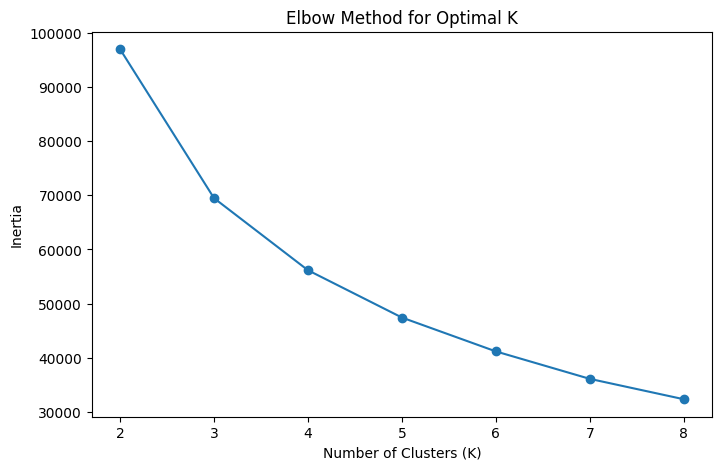

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 9), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [13]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df['Cluster'].value_counts().sort_index())

Cluster
0    14367
1     3123
2    22794
3     9716
Name: count, dtype: int64


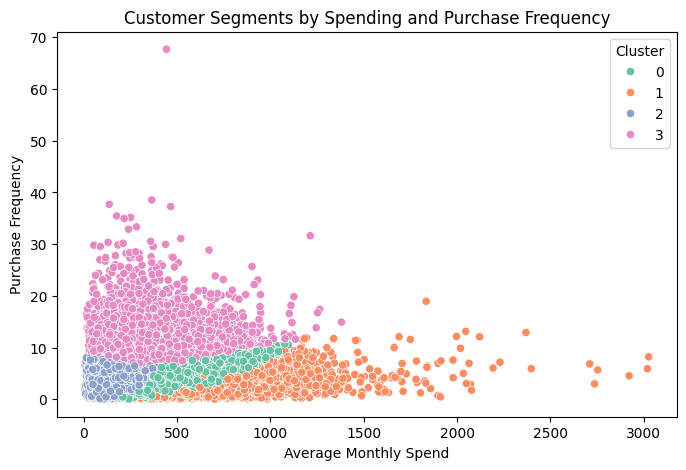

In [14]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='avg_monthly_spend',
    y='purchase_frequency',
    hue='Cluster',
    palette='Set2'
)

plt.title("Customer Segments by Spending and Purchase Frequency")
plt.xlabel("Average Monthly Spend")
plt.ylabel("Purchase Frequency")
plt.show()

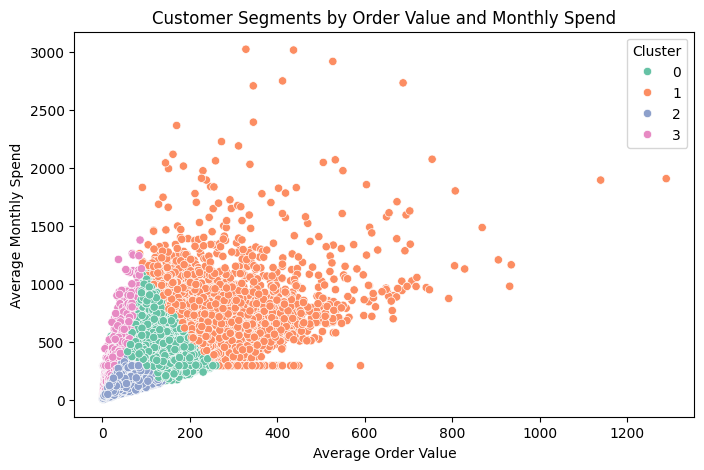

In [15]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='avg_order_value',
    y='avg_monthly_spend',
    hue='Cluster',
    palette='Set2'
)

plt.title("Customer Segments by Order Value and Monthly Spend")
plt.xlabel("Average Order Value")
plt.ylabel("Average Monthly Spend")
plt.show()

In [16]:
cluster_profile = df.groupby('Cluster')[
    ['avg_monthly_spend', 'purchase_frequency', 'avg_order_value']
].mean().round(2)

print(cluster_profile)

         avg_monthly_spend  purchase_frequency  avg_order_value
Cluster                                                        
0                   454.12                3.39           116.95
1                   740.68                2.25           268.25
2                   208.31                3.94            45.96
3                   327.15               10.14            31.21


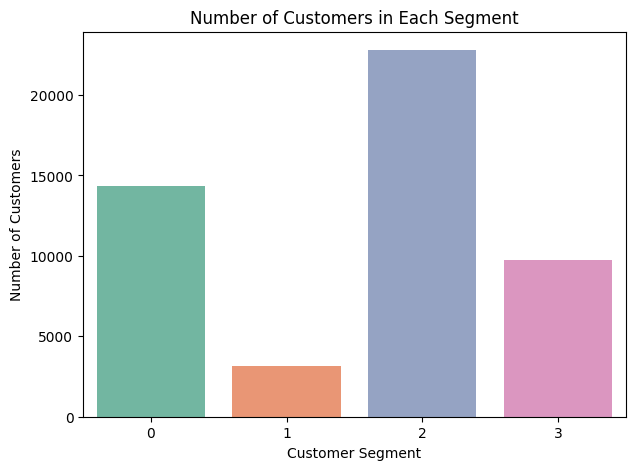

In [17]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Cluster', hue='Cluster', palette='Set2', legend=False)

plt.title("Number of Customers in Each Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.show()

In [18]:
segment_summary = df.groupby('Cluster').agg(
    Customers=('customer_id', 'count'),
    Avg_Spend=('avg_monthly_spend', 'mean'),
    Purchase_Frequency=('purchase_frequency', 'mean'),
    Avg_Order_Value=('avg_order_value', 'mean')
).round(2)

print(segment_summary)

         Customers  Avg_Spend  Purchase_Frequency  Avg_Order_Value
Cluster                                                           
0            14367     454.12                3.39           116.95
1             3123     740.68                2.25           268.25
2            22794     208.31                3.94            45.96
3             9716     327.15               10.14            31.21


## Customer Segment Insights and Marketing Actions

Cluster 0 – Balanced Customers:
Customers show moderate monthly spending, purchase frequency, and order value. They represent a stable customer group.
Marketing action: Use loyalty rewards and personalized offers to encourage repeat purchases.

Cluster 1 – High-Value Customers:
This segment has the highest average monthly spend and average order value, although purchase frequency is lower.
Marketing action: Offer premium products, exclusive deals, and personalized recommendations to increase retention and purchase frequency.

Cluster 2 – Low-Spend Customers:
This is the largest customer segment, with relatively low monthly spending and average order value.
Marketing action: Use introductory offers, product bundles, and targeted discounts to increase spending.

Cluster 3 – Frequent Small-Order Customers:
These customers purchase most frequently but have a low average order value.
Marketing action: Use cross-selling, product bundles, and minimum-order offers to increase basket size.

### Conclusion

K-Means clustering identified four distinct customer segments based on average monthly spending, purchase frequency, and average order value. The segments show different purchasing behaviours, from high-value customers to frequent small-order customers and low-spend customers. These insights can help businesses design targeted marketing strategies, improve customer engagement, increase order value, and strengthen customer retention.